In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az
import xarray as xr
from scipy.linalg import null_space
from itertools import product

from _utils_spline import eval_spline_basis_equispaced_numeric, difference_matrix

import warnings
warnings.filterwarnings('ignore')

In [11]:
replications = 500

In [12]:
# True values
def f1(x):
    return x/1.758
def f2(x):
    return x**2/2.75 - 1.5
def f3(x):
    return np.sin(x)/0.72

f_value = [f1, f2, f3]
sigma_value = [1, 0.5, 0.33]

f_sigma_value = list(product(f_value, sigma_value))

In [14]:
# Generating data
data = {(f.__name__, sigma): {} for f, sigma in f_sigma_value}

n = 100
for f, sigma in f_sigma_value:
    for i in range(replications):
        x = np.random.uniform(-3, 3, n)
        f_evaluated = f(x)
        f_evaluated /= np.std(f_evaluated)
        y = f_evaluated + np.random.normal(0, sigma, n)
        data[(f.__name__, sigma)][i] = (x, y)


In [15]:
model_data = data[('f1', 0.33)][0]
x_data = model_data[0]
x_data_order = np.argsort(x_data)
y_data = model_data[1]

a = 1
b = 0.005

In [54]:
spline_degree = 3
pen_order = 2
n_internal_knots = 20

implementation = 'standard'
implementation = 'centring+dropping'
implementation = 'conditioning'
implementation = 'spectral'
penalised = True
order = 2

def D(w, k, order, exact):
    if exact:
        raise NotImplementedError("Exact implementation not implemented")
    else:
        Dw = difference_matrix(k, order=order) @ w
        return pt.dot(Dw, Dw)


In [77]:
model = pm.Model()
with model:
    # Priors
    beta_0 = pm.Normal('beta_0', mu=0, sigma=100)
    sigma_2 = pm.InverseGamma('sigma_2', alpha=a, beta=b)

    tau = pm.Gamma("tau", alpha=a, beta=b)
    #tau = pm.Deterministic("tau", pt.as_tensor_variable(1.0))
    if penalised:
        #tau_p = pm.Gamma("tau_p", alpha=a, beta=b)
        tau_p = pm.Deterministic("tau_p", pt.as_tensor_variable(1.0))

    # Spline implementation
    eval_B = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_data)
    B = eval_B['B']
    k = B.shape[1]
    K = difference_matrix(k, order=order).T @ difference_matrix(k, order=order)
    if implementation=='standard':
        X = B.copy()
        if penalised:
            Q = tau_p * K + tau * np.eye(k)
        else:
            Q =tau * np.eye(k)
        w = pm.MvNormal("w", mu=np.zeros(k), tau=Q, shape=k)
        f = pm.math.dot(X, w)

    eta = beta_0 + f
    # Likelihood
    y_obs = pm.Normal('y_obs', mu=eta, sigma=np.sqrt(sigma_2), observed=y_data)

In [ ]:
model = pm.Model()
with model:
    # Priors
    beta_0 = pm.Normal('beta_0', mu=0, sigma=100)
    sigma_2 = pm.InverseGamma('sigma_2', alpha=a, beta=b)

    if not penalised:
        tau = pm.Gamma("tau", alpha=a, beta=b)
        #tau = pm.Deterministic("tau", pt.as_tensor_variable(1.0))
    else:
        tau = pm.Gamma("tau", alpha=a, beta=b)
        tau_p = pm.Gamma("tau_p", alpha=a, beta=b)
        #tau_p = pm.Deterministic("tau_p", pt.as_tensor_variable(1.0))

    # Spline implementation
    eval_B = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_data)
    B = eval_B['B']
    k = B.shape[1]

    x_plot = np.linspace(np.min(x_data), np.max(x_data), 500)
    eval_B_plot = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_plot)
    B_plot = eval_B_plot['B'][:, :]

    if implementation=='standard': # standard = full B splines, unidentifiable, use for posterior centring evaluation
        X = B.copy()
        w = pm.Normal("w",mu=0, tau=tau, shape=k, dims="w_dim")
        if penalised:
            Dw = pt.dot(difference_matrix(k, order=order), w)
            K = difference_matrix(k, order=order).T @ difference_matrix(k, order=order)
            penalty = pt.dot(Dw, Dw)
            Q = tau_p * K + tau * np.eye(k)
            sign, logdet = pt.linalg.slogdet(Q)
            pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                           - 0.5 * k * pt.log(tau)
                                           + 0.5 * logdet)
        f = pm.math.dot(X, w)

    elif implementation=='centring+dropping': # centring+dropping = Gressani implementation, adjusted penalty
        X = B.copy()
        X = X - X.mean(axis=0)  # centre the basis functions
        X = X[:, :-1]  # drop the last column to ensure identifiability

        w = pm.Normal("w",mu=0, tau=tau, shape=k-1, dims="w_dim")
        if penalised:
            Dw = pt.dot(difference_matrix(k, order=order)[:, :-1], w)
            K = difference_matrix(k, order=order)[:, :-1].T @ difference_matrix(k, order=order)[:, :-1]
            penalty = pt.dot(Dw, Dw)
            Q = tau_p * K + tau * np.eye(k-1)
            sign, logdet = pt.linalg.slogdet(Q)
            pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                           - 0.5 * (k-1) * pt.log(tau)
                                           + 0.5 * logdet)
        f = pm.math.dot(X, w)

    elif implementation=='conditioning': # conditioning = Chen implementation, map to constrained conditioned space
        X = B.copy()
        Z = null_space(np.ones((X.shape[0], 1)).T @ X)
        ZTZ = Z.T @ Z
        theta = pm.MvNormal("theta", mu=np.zeros(Z.shape[1]), tau=tau*ZTZ, shape=Z.shape[1], dims="theta_dim")

        model.add_coord("w_dim", range(k))
        w = pm.Deterministic("w", pt.dot(Z,theta), dims="w_dim")
        if penalised:
            Dw = pt.dot(difference_matrix(k, order=order)[:, :], w)
            K = difference_matrix(k, order=order)[:, :].T @ difference_matrix(k, order=order)[:, :]
            penalty = pt.dot(Dw, Dw)
            Q = tau_p * K + tau * np.eye(k)
            sign, logdet = pt.linalg.slogdet(Q)
            pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                           - 0.5 * (k-1) * pt.log(tau)
                                           + 0.5 * logdet)
        f = pm.math.dot(X, w)
    
    elif implementation=='spectral': # spectral = scheipl implementatin, decompose improper prior
        X = B.copy()
        X = X - X.mean(axis=0)  # centre the basis functions
        X = X[:, :] 

        
        # if not penalised this is the standard implementation, needs improper prior for decomposition
        if penalised:
            # Penalised
            K = difference_matrix(k, order=order)[:, :].T @ difference_matrix(k, order=order)[:, :]
            K_pinv = np.linalg.pinv(K)
            V, U = np.linalg.eigh(X@K@X.T)
            r = k - order
            Vp = V[-r:]
            Up = U[:, -r:]
            U0 = U[:, :-r]
            Xp = Up*np.sqrt(Vp)
            
            # Unpenalised
            w_trend = np.arange(k)
            w_trends = np.array([w_trend**d for d in range(1, order)]).T
            w_trends = w_trends - w_trends.mean(axis=0)
            X0 = X@w_trends
            X0_plot = B_plot@w_trends
            X0 = X0 / (np.max(X0_plot, axis=0) - np.min(X0_plot, axis=0))

            wp = pm.Normal("wp",mu=0, tau=tau_p, shape=r, dims="wp_dim")
            w0 = pm.Normal("w0", mu=0, tau=tau, shape=(order-1), dims="w0_dim")
            f = pm.math.dot(Xp, wp) + pm.math.dot(X0, w0)
        else:
            w = pm.Normal("w",mu=0, tau=tau, shape=k, dims="w_dim")
            print("Unpenalised Spectral = standard implementation")
            f = pm.math.dot(X, w)

    eta = beta_0 + f
    # Likelihood
    y_obs = pm.Normal('y_obs', mu=eta, sigma=np.sqrt(sigma_2), observed=y_data)

In [64]:
n_tune = 1000
n_draws = 1000
n_chains = 4
n_cores = 4

In [65]:
with model:
    idata = pm.sample(tune = n_tune,
                    draws = n_draws,
                    chains = n_chains,
                    random_seed=42,
                    cores = n_cores,
                    discard_tuned_samples=True,
                    progressbar=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, sigma_2, tau, tau_p, w, w_trend]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [102]:
w_post = idata.posterior["w"]

w_centered = w_post - w_post.mean(dim="w_dim_0")  # adjust dim name if needed

idata.posterior["w_centered"] = w_centered

In [68]:
az.summary(idata, var_names=['sigma_2','tau_p','w_trend'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_2,0.127,0.020,0.092,0.163,0.000,0.000,2658.0,2653.0,1.00
tau_p,196.712,183.074,13.964,506.366,9.311,13.172,380.0,856.0,1.01
w_trend[0],3.250,0.124,3.015,3.477,0.002,0.002,3836.0,2857.0,1.00


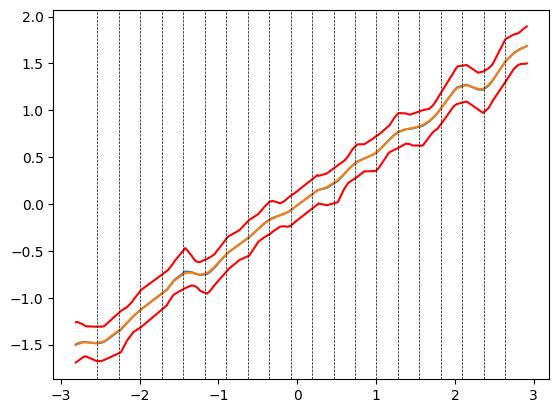

In [72]:
B_post = np.dot(Xp, idata.posterior['w'].values.reshape(n_chains*n_draws, r).T) + np.dot(X0, idata.posterior['w_trend'].values.reshape(n_chains*n_draws, order-1).T)
B_post = B_post - np.mean(B_post, axis=0)
B_post_mean = B_post.mean(axis=1)
B_post_median = np.median(B_post, axis=1)
B_post_975 = np.percentile(B_post, 97.5, axis=1)
B_post_025 = np.percentile(B_post, 2.5, axis=1)

plt.plot(x_data[x_data_order], B_post_mean[x_data_order])
plt.plot(x_data[x_data_order], B_post_median[x_data_order])
plt.plot(x_data[x_data_order], B_post_975[x_data_order], c='r')
plt.plot(x_data[x_data_order], B_post_025[x_data_order], c='r')
for knot in interior_knots:
    plt.axvline(knot, c='k', ls='--', lw=0.5)
plt.show()

In [52]:
x_plot = np.linspace(np.min(x_data), np.max(x_data), 500)
eval_B_plot = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_plot)
B_plot = eval_B_plot['B'][:, :]
interior_knots = eval_B_plot['interior_knots']
B_post = np.dot(B_plot, idata.posterior['w'].values.reshape(n_chains*n_draws, k).T)
B_post = B_post - np.mean(B_post, axis=0)
B_post_mean = B_post.mean(axis=1)
B_post_median = np.median(B_post, axis=1)
B_post_975 = np.percentile(B_post, 97.5, axis=1)
B_post_025 = np.percentile(B_post, 2.5, axis=1)

In [125]:
x_plot = np.linspace(np.min(x_data), np.max(x_data), 500)
eval_B_plot = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_plot)
B_plot = eval_B_plot['B'][:, :-1]
interior_knots = eval_B_plot['interior_knots']
B_post = np.dot(B_plot, idata.posterior['w'].values.reshape(n_chains*n_draws, k-1).T)
B_post = B_post - np.mean(B_post, axis=0)
B_post_mean = B_post.mean(axis=1)
B_post_median = np.median(B_post, axis=1)
B_post_975 = np.percentile(B_post, 97.5, axis=1)
B_post_025 = np.percentile(B_post, 2.5, axis=1)

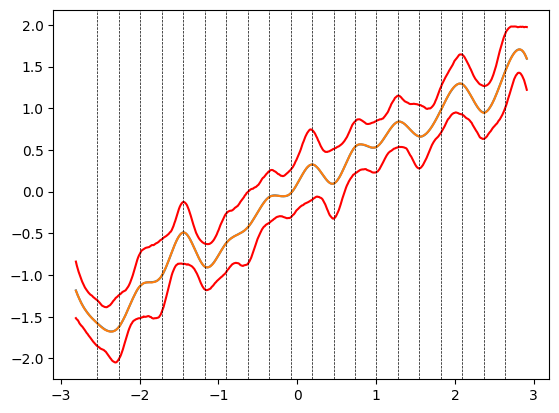

In [53]:
plt.plot(x_plot, B_post_mean[:])
plt.plot(x_plot, B_post_median[:])
plt.plot(x_plot, B_post_975[:], c='r')
plt.plot(x_plot, B_post_025[:], c='r')
for knot in interior_knots:
    plt.axvline(knot, c='k', ls='--', lw=0.5)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (100,) and (500,)

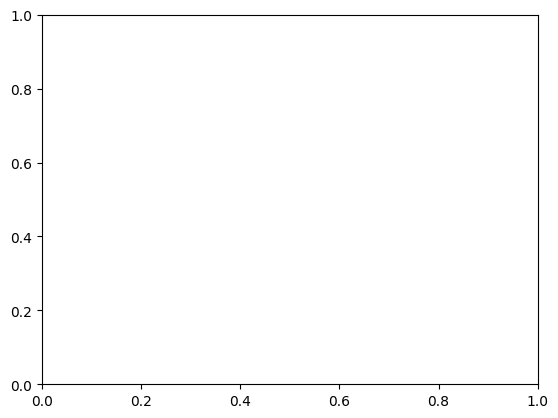

In [ ]:
plt.plot(x_data[x_data_order], B_post_mean[x_data_order])
plt.plot(x_data[x_data_order], B_post_median[x_data_order])
plt.plot(x_data[x_data_order], B_post_975[x_data_order], c='r')
plt.plot(x_data[x_data_order], B_post_025[x_data_order], c='r')
plt.show()